# Verify `_add.pkl` cache labels against `metrics_out/`

Loads a relabeled cache (`dataset_cache_<brain>_mcl<N>_add.pkl`), rebuilds the
per-neuron split / merge / omit statistics **from the baked-in canonical labels
alone** (no segmentation read), and compares them to the canonical
`metrics_out/<brain>/<seg_id>/results.csv`.

## Should these match exactly?

**Close — and the residual gaps are explainable, not bugs.** The cache stores
fragments that were filtered at `min_cable_length` (100 µm), while the canonical
pipeline scores against the *unfiltered* skeletons. With the canonical merge
definition now fully reproduced — node-count rule **plus the geometric fragment
walk** (`MergeCountMetric`), baked into the cache as `gt_merge_labels` — the
expected behavior is:

- **% Omit Edges** — cache-only runs slightly **higher** (filtered-out short
  fragments leave GT stretches unlabeled → counted as omit). Upper bound on the
  true miss rate.
- **# Splits / % Split Edges** — cache-only runs slightly **lower / comparable**
  (fewer fragments → fewer distinct segments touching a neuron).
- **% Merged Edges** — should now track canonical **closely**, including the
  merge-heavy neurons (e.g. N013, N018) that the node-count rule alone missed,
  because the geometric walk recovers grazing fusions.
- **Edge Accuracy** — tracks canonical within the omit + residual-merge gaps.

The point of this notebook is to confirm the numbers are *consistent in shape*
(same neurons, same ranking, gaps in the expected direction and magnitude) — not
byte-equal. Kernel: **panda**.

> Requires an `_add.pkl` built with the geometric walk (current `relabel_cache.py`).
> Rerun `scripts/relabel_cache.py --brain <id>` if the merge labels look empty.

## 0. Setup

In [ ]:
import os, sys, glob, pickle
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

REPO = "/allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent"
sys.path.insert(0, os.path.join(REPO, "agentic-neuron-proofreader/src"))

from agentic_neuron_proofreader.data_modules import canonical_labeling as cl
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset

# Brain to verify. 789202 is the one with a results.csv in metrics_out/ here.
BRAIN_ID = "789202"
MINLEN = 100

CACHE_DIR = os.path.join(REPO, "exa-spim-agent/cache")
METRICS_DIR = os.path.join(REPO, "exa-spim-agent/metrics_out")
ADD_PATH = os.path.join(CACHE_DIR, f"dataset_cache_{BRAIN_ID}_mcl{MINLEN}_add.pkl")
print("add cache:", ADD_PATH, "\nexists:", os.path.exists(ADD_PATH))

## 1. Load the `_add.pkl` cache and confirm the labels are present

A relabeled cache carries `gt_node_canonical_label` and `gt_edge_error` (also
restored onto `gt_graph` as `node_label` / `edge_error`). If these are missing,
the cache was not relabeled — run `scripts/relabel_cache.py` first.

In [2]:
ds = BrainDataset.load_from_cache(ADD_PATH)
gt = ds.gt_graph

assert getattr(gt, "node_label", None) is not None, \
    "node_label missing — this cache was not relabeled (run relabel_cache.py)."
assert getattr(gt, "edge_error", None) is not None, \
    "edge_error missing — this cache was not relabeled."

node_label = np.asarray(gt.node_label)
edge_error = np.asarray(gt.edge_error)
n_labeled = int((node_label != cl.UNLABELED).sum())

print(gt.summary(prefix="GroundTruth"))
print(f"\nnode_label: shape={node_label.shape}, labeled={n_labeled:,} "
      f"({100*n_labeled/node_label.size:.1f}%)")
print(f"edge_error: shape={edge_error.shape}, classes="
      + ", ".join(f"{cl.EDGE_ERROR_NAMES[c]}={int((edge_error==c).sum())}"
                  for c in cl.EDGE_ERROR_NAMES))
print("segmentation_path:", ds.segmentation_path)

GroundTruth Graph
# Connected Components: 12
# Nodes: 1,409,057
# Edges: 1,409,045
Memory Consumption: 77.91 GBs

node_label: shape=(1409057,), labeled=1,369,807 (97.2%)
edge_error: shape=(1409045,), classes=correct=1109034, split=6805, omit=44690, merged=248516
segmentation_path: gs://allen-nd-goog/from_google/789202/whole_brain/raw.unet_r3_ckpt_425250_seedfix_overlapfix_rempm/


## 2. Whole-brain summary from the labels (no segmentation read)

`canonical_labeling.summarize` reproduces the same totals `relabel_cache.py`
printed — a quick self-consistency check that the stored arrays load cleanly.

In [ ]:
# Merge labels stored in the cache = union of node-count rule + geometric walk
# (reproduces canonical labels_with_merge). Fall back to node-count-only if the
# cache predates the geometric walk.
merge_label_set = set(int(x) for x in (getattr(gt, "merge_labels", None)
                                       if getattr(gt, "merge_labels", None) is not None else []))
if not merge_label_set:
    merge_label_set = cl.merge_labels(gt, node_label)
    print("note: no stored geometric merge labels; using node-count rule only "
          "(rerun relabel_cache.py to bake the geometric walk in)")
print(f"merge labels: {len(merge_label_set)}")

# Merge SITES are a separate artifact, and the ONLY source of canonical "# Merges".
# A segment can carry several sites, so len(merge_sites) >= len(merge_label_set).
merge_sites = list(getattr(gt, "merge_sites", None) or [])
print(f"merge sites : {len(merge_sites)}")
if not merge_sites:
    print("note: no stored gt_merge_sites; '# Merges' cannot be compared "
          "(rerun relabel_cache.py to bake the geometric walk in)")

summary = cl.summarize(gt, node_label, edge_error, merge_label_set=merge_label_set)
for k, v in summary.items():
    print(f"  {k:<18}: {v:.3f}" if isinstance(v, float) else f"  {k:<18}: {v}")

# summarize()['total_merges'] is NOT canonical '# Merges'. It computes
# sum(max(k - 1, 0)) with k = neurons carrying > MERGE_MIN_NODES nodes of the
# segment, so a SINGLE-TRACED-NEURON merge -- the geometric walk's
# untraced-excursion case, where k == 1 -- contributes 0 events. Canonical counts
# one event per SITE. The site count is not derivable from the node labels alone
# (sites need the fragments graph), which is why this labels-only summary cannot
# produce it. Compare len(merge_sites); never total_merges.
if merge_sites:
    print(f"\n  total_merges (node-count sum(max(k-1,0))) : {summary['total_merges']}")
    print(f"  # Merges (canonical, one per site)        : {len(merge_sites)}")
    if summary["total_merges"] != len(merge_sites):
        gap = len(merge_sites) - summary["total_merges"]
        print(f"  -> differ by {gap:+d} BY CONSTRUCTION; the site count is canonical.")


## 3. Per-neuron statistics from the cache labels

Build one row per GT neuron, mirroring the columns in `results.csv`. Both
endpoints of a GT edge live on the same neuron, so we label each edge by the GT
neuron of one endpoint and tally its class from `edge_error`.

- **# Splits** = (distinct predicted segments touching the neuron) − 1
- **% Split / Omit Edges** = class fraction of that neuron's GT edges
- **% Merged Edges** = canonical node-based formula `Σ (nodes_of_merge_label − 1)`
  over the union merge-label set (node-count rule + geometric walk), ÷ neuron edges
- **Edge Accuracy** = % correct edges
- **SWC Run Length** = cable length (µm), from the graph geometry

In [ ]:
edges = list(gt.edges)

# neuron -> {class: edge count}, and neuron -> set of predicted segments on it
neuron_class = defaultdict(lambda: defaultdict(int))
neuron_segs = defaultdict(set)

for k, (i, j) in enumerate(edges):
    neuron = gt.node_segment_id(i)            # GT neuron name (both ends agree)
    neuron_class[neuron][int(edge_error[k])] += 1

for n in gt.nodes:
    lab = int(node_label[n])
    if lab != cl.UNLABELED:
        neuron_segs[gt.node_segment_id(n)].add(lab)

# --- Merged edges, the CANONICAL way -----------------------------------------
# Canonical % Merged Edges is NOT a graph-edge fraction: it is
#   sum over merge-labels on the neuron of (nodes_of_that_label_on_neuron - 1),
# divided by the neuron's edge count, over labels_with_merge -- the UNION of the
# node-count rule and the geometric fragment walk (merge_label_set from above).
seg_neuron_counts = cl.segment_neuron_node_counts(gt, node_label)
neuron_merged_edges = defaultdict(int)
for lab in merge_label_set:
    for neuron, c in seg_neuron_counts.get(lab, {}).items():
        neuron_merged_edges[neuron] += max(c - 1, 0)

# Cable length (µm) per neuron via connected components.
import networkx as nx
neuron_cable = {}
for comp in nx.connected_components(gt):
    root = next(iter(comp))
    neuron_cable[gt.node_segment_id(root)] = gt.cable_length(root=root)

# --- # Merges, the CANONICAL way ----------------------------------------------
# One event per merge SITE, grouped by the neuron the site was found on. This is
# what results.csv '# Merges' counts. Deliberately NOT summarize()'s
# sum(max(k-1,0)) node-count formula, which scores 0 for a single-traced-neuron
# merge and so cannot see the ones the geometric walk exists to find.
neuron_merges = Counter(s["gt_neuron"] for s in merge_sites)

rows = []
for neuron, classes in neuron_class.items():
    tot = sum(classes.values())
    n_split = classes.get(cl.EDGE_SPLIT, 0)
    n_omit = classes.get(cl.EDGE_OMIT, 0)
    n_correct = classes.get(cl.EDGE_CORRECT, 0)
    rows.append({
        "neuron": neuron,
        "SWC Run Length": neuron_cable.get(neuron, np.nan),
        "# Splits": max(len(neuron_segs[neuron]) - 1, 0),
        "# Merges": neuron_merges.get(neuron, 0),
        "% Split Edges": 100.0 * n_split / tot if tot else 0.0,
        "% Omit Edges": 100.0 * n_omit / tot if tot else 0.0,
        # canonical node-based formula over the union merge-label set
        "% Merged Edges": 100.0 * neuron_merged_edges[neuron] / tot if tot else 0.0,
        "Edge Accuracy": 100.0 * n_correct / tot if tot else 0.0,
    })

cache_df = pd.DataFrame(rows).set_index("neuron").sort_index()
print(f"{len(cache_df)} neurons")
cache_df

## 4. Load canonical `results.csv` and align on neuron name

In [5]:
hits = glob.glob(os.path.join(METRICS_DIR, BRAIN_ID, "*", "results.csv"))
assert hits, f"no results.csv under {METRICS_DIR}/{BRAIN_ID}"
canon_df = pd.read_csv(sorted(hits)[0], index_col=0).sort_index()
print("canonical:", sorted(hits)[0])
print(f"{len(canon_df)} neurons")

common = sorted(set(cache_df.index) & set(canon_df.index))
only_cache = sorted(set(cache_df.index) - set(canon_df.index))
only_canon = sorted(set(canon_df.index) - set(cache_df.index))
print(f"\ncommon neurons: {len(common)}")
if only_cache:
    print(f"only in cache : {only_cache}")
if only_canon:
    print(f"only in canon : {only_canon}")
canon_df

canonical: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/metrics_out/789202/raw.unet_r3_ckpt_425250_seedfix_overlapfix_rempm/results.csv
12 neurons

common neurons: 12


,SWC Run Length,# Splits,# Merges,% Split Edges,% Omit Edges,% Merged Edges,ERL,Normalized ERL,Edge Accuracy,Split Rate,Merge Rate
N005-789202-SP,6.600023e+05,1061.0,9,0.421502,3.948402,8.648018,2916.69,0.0044,86.98,594.87,70128.98
N006-789202-JG,1.093291e+06,1200.0,11,0.285244,1.155553,14.679720,5038.70,0.0046,83.88,897.95,97958.09
N007-789202-PP,4.018429e+05,582.0,5,0.370824,5.354540,2.313584,2336.16,0.0058,91.96,650.92,75767.19
N010-789202-JT,4.555105e+05,1390.0,3,0.936992,5.037188,3.984077,1403.83,0.0031,90.04,308.13,142765.84
N011-789202-IG,3.589280e+05,675.0,1,0.481845,3.594476,1.795562,2027.03,0.0056,94.13,510.07,344296.97
N013-789202-KS,9.324719e+05,782.0,37,0.212215,1.837686,41.040640,3161.85,0.0034,56.91,1167.98,24685.33
N016-789202-HP,1.050328e+06,641.0,11,0.177426,0.620928,14.954279,6306.73,0.0060,84.25,1625.49,94722.03
N018-789202-JM,1.237078e+06,564.0,4,0.115830,0.244194,42.930046,4159.44,0.0034,56.71,2185.50,308156.08
N020-789202-PP,3.490545e+05,357.0,1,0.290955,0.817224,7.863124,9296.58,0.0266,91.03,966.91,345186.31
N021-789202-HP,6.863528e+05,616.0,7,0.231252,1.998720,3.209231,6072.15,0.0088,94.56,1089.36,95863.91


## 5. Side-by-side comparison

For each shared column we show cache vs canonical and their difference. Read the
signs against the expectations in the header:

- `% Omit Edges` — **cache ≥ canonical** (filtering inflates omits).
- `# Splits`, `% Split Edges`, `Edge Accuracy` — close, no systematic large bias.
- `% Merged Edges` — should now be **close** across all neurons (node-count rule
  + geometric walk). A residual on a few neurons is the small set of merge labels
  the canonical dedup/branch-snapping handles slightly differently.

In [ ]:
compare_cols = ["# Splits", "# Merges", "% Split Edges", "% Omit Edges",
                "% Merged Edges", "Edge Accuracy"]

cmp = pd.DataFrame(index=common)
for col in compare_cols:
    cmp[(col, "cache")] = cache_df.loc[common, col]
    cmp[(col, "canon")] = canon_df.loc[common, col]
    cmp[(col, "diff")] = cache_df.loc[common, col] - canon_df.loc[common, col]
cmp.columns = pd.MultiIndex.from_tuples(cmp.columns)

with pd.option_context("display.float_format", lambda v: f"{v:.2f}"):
    display(cmp)

print("\nMean difference (cache - canon) across neurons:")
for col in compare_cols:
    d = cmp[(col, "diff")]
    print(f"  {col:<16}: mean={d.mean():+.2f}  median={d.median():+.2f}  "
          f"|max|={d.abs().max():.2f}")

## 6. Consistency checks (shape, not equality)

We assert the relationships that *should* hold, and only warn (don't fail) on the
ones expected to diverge. A FAIL here points to a real labeling problem; a WARN
is the documented filtering/definition gap.

In [ ]:
def report(name, ok, detail="", hard=True):
    tag = ("PASS" if ok else "FAIL") if hard else ("OK" if ok else "WARN")
    print(f"[{tag}] {name}" + (f"  ->  {detail}" if detail else ""))
    return ok

# Same neuron set (hard): the cache and canonical should trace the same neurons.
report("same GT neuron set", not only_cache and not only_canon,
       f"cache-only={only_cache}, canon-only={only_canon}")

# Omit should be inflated cache-side, not deflated (hard direction check).
omit_diff = cmp[("% Omit Edges", "diff")]
report("% Omit Edges: cache >= canonical (filtering inflates omits)",
       (omit_diff >= -0.5).all(),
       f"min diff={omit_diff.min():+.2f}, mean={omit_diff.mean():+.2f}")

# Split %, # Splits, Edge Accuracy should correlate strongly across neurons.
for col in ["Edge Accuracy", "% Split Edges", "# Splits"]:
    r = np.corrcoef(cache_df.loc[common, col], canon_df.loc[common, col])[0, 1]
    report(f"{col}: cache vs canonical correlated (r > 0.7)", r > 0.7,
           f"r={r:.3f}", hard=False)

# Merged edges now use the full canonical definition (node-count + geometric
# walk) -> expect strong correlation and a modest mean gap.
md = cmp[("% Merged Edges", "diff")]
r_merge = np.corrcoef(cache_df.loc[common, "% Merged Edges"],
                      canon_df.loc[common, "% Merged Edges"])[0, 1]
report("% Merged Edges: cache vs canonical correlated (r > 0.7)",
       r_merge > 0.7, f"r={r_merge:.3f}", hard=False)
report("% Merged Edges: mean |diff| within 5 pts",
       md.abs().mean() < 5, f"mean |diff|={md.abs().mean():.2f}", hard=False)

# --- # Merges: site counts ----------------------------------------------------
# Direction is HARD. The cache's fragments were filtered at min_cable_length, so
# the walk can only MISS sites canonical found -- never invent extra ones. A cache
# count ABOVE canonical is a real bug (double counting, or a dedup that did not
# run), not a documented filtering gap.
if merge_sites:
    mg = cmp[("# Merges", "diff")]
    report("# Merges: cache <= canonical (filtering can only lose sites)",
           bool((mg <= 0).all()),
           f"max diff={mg.max():+.0f}" + (f" on {mg.idxmax()}" if len(mg) else ""))
    report("# Merges: mean |diff| per neuron < 1.0",
           mg.abs().mean() < 1.0, f"mean |diff|={mg.abs().mean():.2f}", hard=False)
    tot_cache = int(cache_df.loc[common, "# Merges"].sum())
    tot_canon = int(canon_df.loc[common, "# Merges"].sum())
    rel = abs(tot_cache - tot_canon) / max(tot_canon, 1)
    report("# Merges: total within 15% of canonical", rel < 0.15,
           f"cache={tot_cache}, canon={tot_canon}, rel diff={rel:.1%}", hard=False)
    print("     (a large deficit here with '% Merged Edges' still correlating is "
          "consistent:\n      % Merged Edges counts a label's cable as soon as the "
          "label is in the union,\n      so it is insensitive to how many SITES the "
          "walk actually located.)")
    print("     For site positions and the coordinate frame, run "
          "verify_add_cache_merge_info.py.")

print("\nFAIL = real problem to investigate; WARN = documented filtering/definition gap.")
print("(If % Merged Edges is still far off on N013/N018, the geometric walk was not")
print(" baked in -- rerun relabel_cache.py so gt_merge_labels is populated.)")

## 7. Scatter: cache vs canonical per neuron

Points on the diagonal = agreement. Systematic offset from the diagonal = the
expected filtering/definition gap (e.g. omit points sitting above the line).

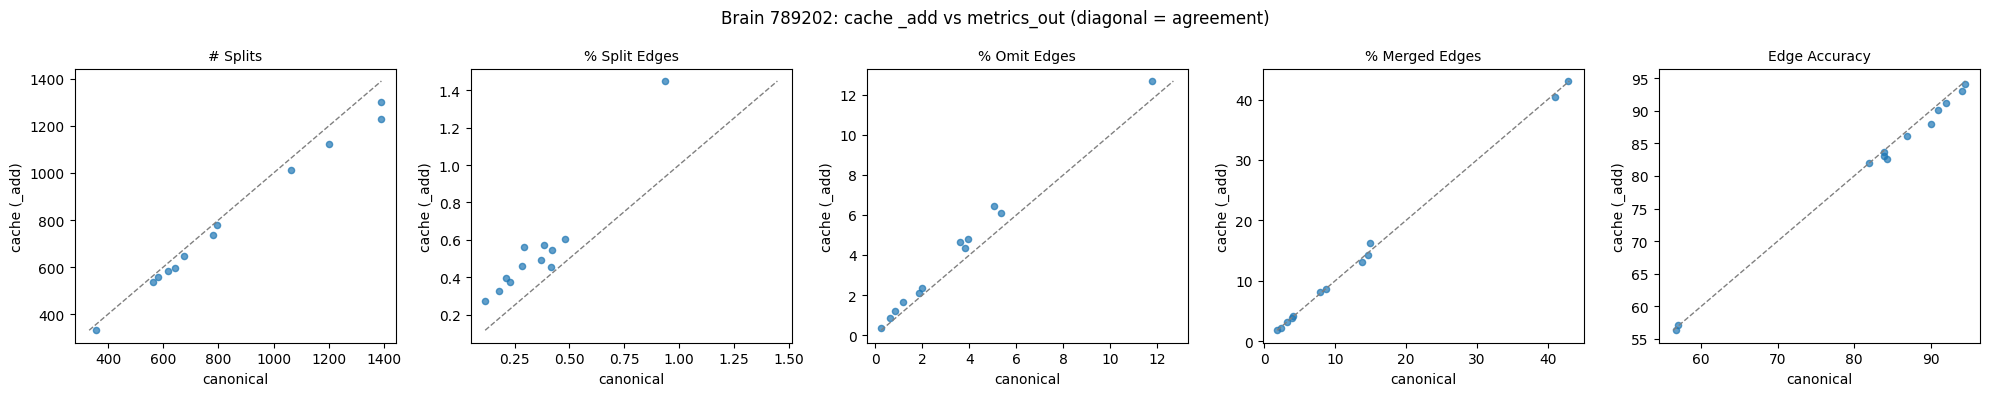

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(compare_cols), figsize=(4 * len(compare_cols), 4))
for ax, col in zip(axes, compare_cols):
    x = canon_df.loc[common, col].values
    y = cache_df.loc[common, col].values
    ax.scatter(x, y, s=20, alpha=0.7)
    lo = float(min(x.min(), y.min()))
    hi = float(max(x.max(), y.max()))
    ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1)
    ax.set_xlabel(f"canonical")
    ax.set_ylabel(f"cache (_add)")
    ax.set_title(col, fontsize=10)
fig.suptitle(f"Brain {BRAIN_ID}: cache _add vs metrics_out (diagonal = agreement)")
fig.tight_layout()
plt.show()

## 8. Persist the result for cross-dataset comparison

Save the section-7 result to `notebooks/verify_stats/` so it can be reloaded and
compared across brains without rerunning the (heavy) cache load. Everything is
keyed by `brain_id` so the files concatenate cleanly:

- `verify_stats/<brain>_per_neuron.csv` — one row per neuron, flat columns
  (`<metric>_cache`, `<metric>_canon`, `<metric>_diff`) plus `SWC Run Length`.
- `verify_stats/<brain>_summary.csv` — one row for the brain: per-metric
  mean/median/|max| diff, cache-vs-canon correlations, and the section-6
  consistency verdicts.
- `verify_stats/<brain>_scatter.png` — the section-7 figure.

The next cell reloads every brain's `*_per_neuron.csv` / `*_summary.csv` into two
combined frames for side-by-side analysis.

In [9]:
VERIFY_STATS_DIR = os.path.join(REPO, "exa-spim-agent/notebooks/verify_stats")
os.makedirs(VERIFY_STATS_DIR, exist_ok=True)

# --- per-neuron table: flatten the section-5 MultiIndex into plain columns ----
per_neuron = pd.DataFrame(index=common)
per_neuron.index.name = "neuron"
per_neuron.insert(0, "brain_id", BRAIN_ID)
per_neuron["SWC Run Length_cache"] = cache_df.loc[common, "SWC Run Length"]
per_neuron["SWC Run Length_canon"] = canon_df.loc[common, "SWC Run Length"]
for col in compare_cols:
    per_neuron[f"{col}_cache"] = cmp[(col, "cache")]
    per_neuron[f"{col}_canon"] = cmp[(col, "canon")]
    per_neuron[f"{col}_diff"] = cmp[(col, "diff")]

per_neuron_path = os.path.join(VERIFY_STATS_DIR, f"{BRAIN_ID}_per_neuron.csv")
per_neuron.to_csv(per_neuron_path)

# --- one-row brain summary: diffs, correlations, consistency verdicts ---------
srow = {"brain_id": BRAIN_ID, "min_cable_length": MINLEN,
        "n_neurons": len(common), "segmentation_path": ds.segmentation_path}
for col in compare_cols:
    d = cmp[(col, "diff")]
    r = float(np.corrcoef(cache_df.loc[common, col], canon_df.loc[common, col])[0, 1])
    safe = col.strip("# ").replace("% ", "pct_").replace(" ", "_").lower()
    srow[f"{safe}_mean_diff"] = float(d.mean())
    srow[f"{safe}_median_diff"] = float(d.median())
    srow[f"{safe}_max_abs_diff"] = float(d.abs().max())
    srow[f"{safe}_corr"] = r

omit_diff = cmp[("% Omit Edges", "diff")]
md = cmp[("% Merged Edges", "diff")]
srow["same_neuron_set"] = bool(not only_cache and not only_canon)
srow["omit_inflated_cache_side"] = bool((omit_diff >= -0.5).all())
srow["merged_mean_abs_diff_within_5"] = bool(md.abs().mean() < 5)

summary_df = pd.DataFrame([srow]).set_index("brain_id")
summary_path = os.path.join(VERIFY_STATS_DIR, f"{BRAIN_ID}_summary.csv")
summary_df.to_csv(summary_path)

# --- save the section-7 scatter alongside the tables -------------------------
scatter_path = os.path.join(VERIFY_STATS_DIR, f"{BRAIN_ID}_scatter.png")
fig.savefig(scatter_path, dpi=120, bbox_inches="tight")

print("wrote:")
print(" ", per_neuron_path)
print(" ", summary_path)
print(" ", scatter_path)
summary_df

wrote:
  /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/notebooks/verify_stats/789202_per_neuron.csv
  /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/notebooks/verify_stats/789202_summary.csv
  /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/notebooks/verify_stats/789202_scatter.png


,min_cable_length,n_neurons,segmentation_path,splits_mean_diff,splits_median_diff,splits_max_abs_diff,splits_corr,pct_split_edges_mean_diff,pct_split_edges_median_diff,pct_split_edges_max_abs_diff,...,pct_merged_edges_median_diff,pct_merged_edges_max_abs_diff,pct_merged_edges_corr,edge_accuracy_mean_diff,edge_accuracy_median_diff,edge_accuracy_max_abs_diff,edge_accuracy_corr,same_neuron_set,omit_inflated_cache_side,merged_mean_abs_diff_within_5
brain_id,,,,,,,,,,,,,,,,,,,,,
789202,100,12,gs://allen-nd-goog/from_google/789202/whole_br...,-51.333333,-39.5,160.0,0.997203,0.18138,0.153515,0.512223,...,-0.055407,1.346839,0.999337,-0.760981,-0.754731,2.001596,0.999031,True,True,True


### Reload and compare across datasets

Visualize every brain already saved under `verify_stats/` together. Needs no
cache load — it reads the `*_per_neuron.csv` files written by section 8 and plots
cache vs canonical for each metric, **one color per dataset**. Points on the grey
diagonal = agreement; a brain's cluster sitting off the line is its
filtering/definition gap. Rerun sections 0–8 with a different `BRAIN_ID` to add
more brains, then rerun this cell.

5 dataset(s): 789202, 794491, 794493, 794495, 802449  (88 neurons total)


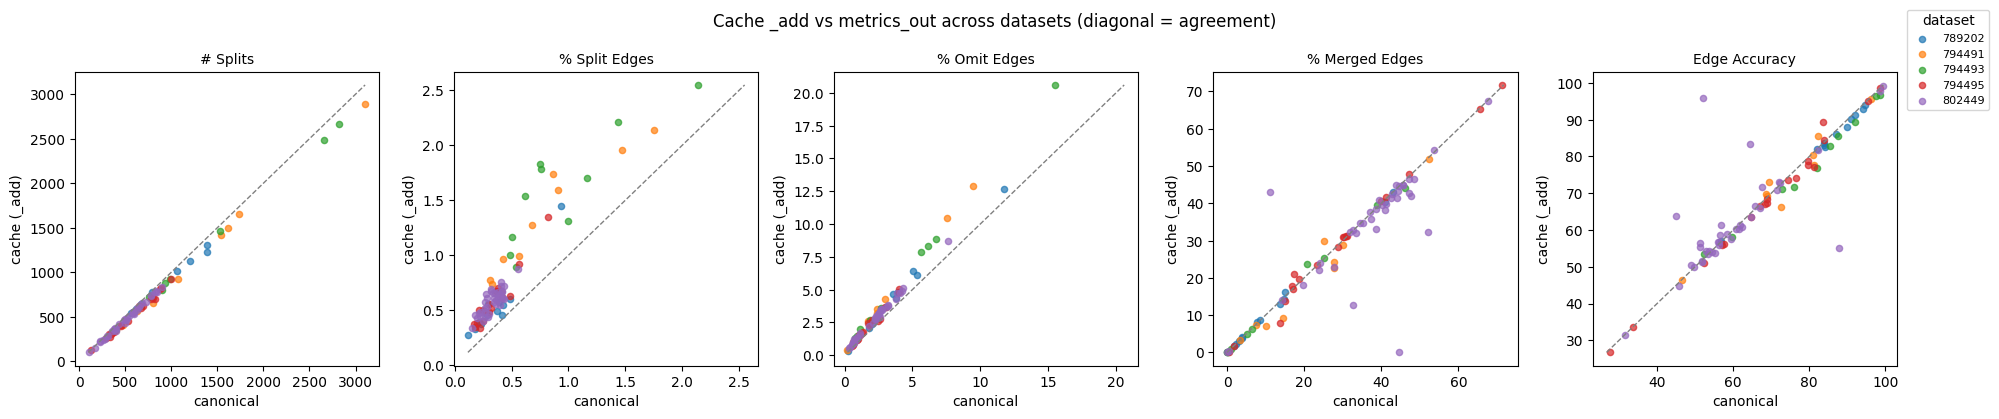

In [10]:
import matplotlib.pyplot as plt

VERIFY_STATS_DIR = os.path.join(REPO, "exa-spim-agent/notebooks/verify_stats")
compare_cols = ["# Splits", "% Split Edges", "% Omit Edges",
                "% Merged Edges", "Edge Accuracy"]

neuron_files = sorted(glob.glob(os.path.join(VERIFY_STATS_DIR, "*_per_neuron.csv")))
assert neuron_files, f"no *_per_neuron.csv under {VERIFY_STATS_DIR} -- run section 8 first."
all_neurons = pd.concat([pd.read_csv(f) for f in neuron_files], ignore_index=True)
all_neurons["brain_id"] = all_neurons["brain_id"].astype(str)
brains = sorted(all_neurons["brain_id"].unique())
print(f"{len(brains)} dataset(s): {', '.join(brains)}  ({len(all_neurons)} neurons total)")

# One color per dataset.
cmap = plt.get_cmap("tab10" if len(brains) <= 10 else "tab20")
colors = {b: cmap(i % cmap.N) for i, b in enumerate(brains)}

fig, axes = plt.subplots(1, len(compare_cols), figsize=(4 * len(compare_cols), 4.2))
for ax, col in zip(axes, compare_cols):
    lo, hi = np.inf, -np.inf
    for b in brains:
        sub = all_neurons[all_neurons["brain_id"] == b]
        x = sub[f"{col}_canon"].values
        y = sub[f"{col}_cache"].values
        ax.scatter(x, y, s=20, alpha=0.7, color=colors[b], label=b)
        lo = min(lo, np.nanmin(x), np.nanmin(y))
        hi = max(hi, np.nanmax(x), np.nanmax(y))
    ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1)
    ax.set_xlabel("canonical")
    ax.set_ylabel("cache (_add)")
    ax.set_title(col, fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="dataset", loc="upper right",
           bbox_to_anchor=(1.0, 1.0), fontsize=8)
fig.suptitle("Cache _add vs metrics_out across datasets (diagonal = agreement)")
fig.tight_layout(rect=[0, 0, 0.96, 1])
plt.show()